# Train YOLOv8m-cls cho Chicken Disease Classification

Train **YOLOv8m-cls (Medium)** để so sánh với YOLOv8n-cls và YOLOv8s-cls đã train trước.

| Thông số | Giá trị |
|----------|--------|
| Model    | YOLOv8m-cls (~17.0M params) |
| Dataset  | 7,617 train / 1,614 val / 4 classes |
| Epochs   | 50 (EarlyStopping patience=10) |
| imgsz    | 224 |
| Batch    | 32 |
| Optimizer| AdamW (lr=0.001) |

> ✓ Kết quả lưu ngay lên Drive sau khi train xong.

> ⚠️ **YOLOv8m-cls ước tính train ~3-4 tiếng trên Colab T4.** Hãy đảm bảo session không bị timeout.

## Bước 0: Cài đặt và Kiểm tra GPU

In [1]:
%pip install ultralytics -q

import os, shutil, time
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from ultralytics import YOLO
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from google.colab import drive

print('=' * 60)
print('KIỂM TRA MÔI TRƯỜNG')
print('=' * 60)
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU  : {torch.cuda.get_device_name(0)}')
    print(f'VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('⚠ Không có GPU! Vào Runtime > Change runtime type > GPU')
print('=' * 60)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
KIỂM TRA MÔI TRƯỜNG
CUDA available: True
GPU  : Tesla T4
VRAM : 15.6 GB


## Bước 1: Mount Google Drive & Cấu hình đường dẫn

In [2]:
drive.mount('/content/drive')

# ============================================================
# ⚙️ CẤU HÌNH (giữ nguyên như n-cls để so sánh công bằng)
# ============================================================
DATA_ROOT    = Path('/content/drive/MyDrive/AI_Chicken/data/data_phan_chicken')
YOLO_DATASET = Path('/content/drive/MyDrive/AI_Chicken/yolo_dataset')
IMAGES_DIR   = DATA_ROOT / 'data'
TRAIN_CSV    = DATA_ROOT / 'train_aug.csv'
VAL_CSV      = DATA_ROOT / 'val.csv'
TRAIN_DIR    = YOLO_DATASET / 'train'
VAL_DIR      = YOLO_DATASET / 'val'

MODEL_NAME   = 'yolov8m-cls'
WEIGHTS      = 'yolov8m-cls.pt'

# Giống hệt n-cls để so sánh công bằng
TRAIN_CONFIG = dict(
    data       = str(YOLO_DATASET),
    epochs     = 50,
    imgsz      = 224,
    batch      = 32,
    device     = 0,
    project    = '/content/drive/MyDrive/AI_Chicken/runs/classify',
    name       = MODEL_NAME,
    exist_ok   = True,
    pretrained = True,
    optimizer  = 'AdamW',
    lr0        = 0.001,
    patience   = 10,
    save       = True,
    val        = True,
    plots      = True,
    verbose    = True,
)

CLASSES_LIST = sorted(['Coccidiosis', 'Healthy', 'New Castle Disease', 'Salmonella'])

print(f'✓ Cấu hình xong! Dataset: {YOLO_DATASET}')

Mounted at /content/drive
✓ Cấu hình xong! Dataset: /content/drive/MyDrive/AI_Chicken/yolo_dataset


## Bước 2: Kiểm tra Dataset (bỏ qua tổ chức lại nếu đã có)

In [3]:
n_train = len(list(TRAIN_DIR.rglob('*.jpg'))) if TRAIN_DIR.exists() else 0
n_val   = len(list(VAL_DIR.rglob('*.jpg')))   if VAL_DIR.exists()   else 0

if n_train > 1000 and n_val > 100:
    print(f'✓ Dataset đã sẵn sàng!')
    print(f'  Train: {n_train} ảnh')
    print(f'  Val  : {n_val} ảnh')
else:
    print('⚠ Dataset chưa tồn tại, đang tổ chức lại...')
    TRAIN_DIR.mkdir(parents=True, exist_ok=True)
    VAL_DIR.mkdir(parents=True, exist_ok=True)

    train_df = pd.read_csv(TRAIN_CSV)
    val_df   = pd.read_csv(VAL_CSV)

    def organize_data(df, target_dir, images_dir):
        for label in df['label'].unique():
            (target_dir / label).mkdir(exist_ok=True)
        for idx, row in df.iterrows():
            src = images_dir / row['images']
            dst = target_dir / row['label'] / row['images']
            if src.exists() and not dst.exists():
                shutil.copy2(src, dst)
            if (idx + 1) % 1000 == 0:
                print(f'  {idx + 1}/{len(df)}...')

    print('Tổ chức train data...')
    organize_data(train_df, TRAIN_DIR, IMAGES_DIR)
    print('Tổ chức val data...')
    organize_data(val_df, VAL_DIR, IMAGES_DIR)
    print('✓ Xong!')

✓ Dataset đã sẵn sàng!
  Train: 7617 ảnh
  Val  : 1614 ảnh


## Bước 3: Train YOLOv8m-cls

> ⏱️ **Ước tính thời gian: ~3-4 tiếng** trên Colab T4.
> Model sẽ được lưu trực tiếp lên Google Drive trong quá trình train.

In [4]:
t_start = time.time()

model = YOLO(WEIGHTS)  # Tự động download pretrained weights
print(f'Model {MODEL_NAME} đã khởi tạo!')

results = model.train(**TRAIN_CONFIG)

elapsed = (time.time() - t_start) / 60
print(f'\n✓ Training hoàn thành! Thời gian: {elapsed:.1f} phút')

BEST_PT = Path(TRAIN_CONFIG['project']) / MODEL_NAME / 'weights' / 'best.pt'
print(f'Best model lưu tại: {BEST_PT}')

Model yolov8m-cls đã khởi tạo!
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/AI_Chicken/yolo_dataset, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8m-cls, nbs=64, nms=False, opset=None, optimize=False, optim

## Bước 4: Đánh giá kết quả

In [5]:
BEST_PT    = Path(TRAIN_CONFIG['project']) / MODEL_NAME / 'weights' / 'best.pt'
best_model = YOLO(str(BEST_PT))

# Validate trên val set
val_metrics   = best_model.val(data=str(YOLO_DATASET), split='val')
# Validate trên train set (kiểm tra overfitting)
train_metrics = best_model.val(data=str(YOLO_DATASET), split='train')

top1_val   = val_metrics.top1
top5_val   = val_metrics.top5
top1_train = train_metrics.top1
gap        = top1_train - top1_val

print('\n' + '=' * 60)
print('KẾT QUẢ VALIDATION - YOLOv8m-cls')
print('=' * 60)
print(f'Top-1 Accuracy (Val)   : {top1_val*100:.2f}%')
print(f'Top-5 Accuracy (Val)   : {top5_val*100:.2f}%')
print(f'Top-1 Accuracy (Train) : {top1_train*100:.2f}%')
print(f'Overfitting Gap        : {gap*100:.2f}%')
if gap < 0.02:
    print('✓ KHÔNG BỊ OVERFITTING (gap < 2%)')
elif gap < 0.05:
    print('⚠ OVERFITTING NHẸ (gap 2-5%)')
else:
    print('✗ BỊ OVERFITTING (gap > 5%)')
print('=' * 60)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8m-cls summary (fused): 42 layers, 15,767,780 parameters, 0 gradients, 41.6 GFLOPs
train: /content/drive/MyDrive/AI_Chicken/yolo_dataset/train... found 7617 images in 4 classes ✅ 
val: /content/drive/MyDrive/AI_Chicken/yolo_dataset/val... found 1614 images in 4 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 0.5±0.2 ms, read: 18.0±7.5 MB/s, size: 32.3 KB)
val: Scanning /content/drive/MyDrive/AI_Chicken/yolo_dataset/val... 1614 images, 0 corrupt: 100% ━━━━━━━━━━━━ 1614/1614 423.1Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 101/101 8.2it/s 12.3s
                   all      0.981          1
Speed: 0.1ms preprocess, 2.2ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
train: /content/drive/MyDrive/AI_Chicken/yolo_dataset/train... found 

## Bước 5: Precision / Recall / F1 từng lớp

In [6]:
all_preds  = []
all_labels = []

print('Đang predict trên validation set...')
for cls in CLASSES_LIST:
    cls_dir = VAL_DIR / cls
    if cls_dir.exists():
        for img_path in cls_dir.glob('*.jpg'):
            r = best_model.predict(str(img_path), save=False, verbose=False)
            all_preds.append(r[0].names[r[0].probs.top1])
            all_labels.append(cls)

precision, recall, f1, support = precision_recall_fscore_support(
    all_labels, all_preds, labels=CLASSES_LIST, zero_division=0
)

print('\n' + '=' * 80)
print('CHI TIẾT METRICS TỪNG LỚP - YOLOv8m-cls')
print('=' * 80)
print(f'{"Lớp":<25} {"Precision":<12} {"Recall":<12} {"F1-Score":<12} {"Support"}')
print('-' * 80)
for i, cls in enumerate(CLASSES_LIST):
    print(f'{cls:<25} {precision[i]:<12.4f} {recall[i]:<12.4f} {f1[i]:<12.4f} {support[i]}')
print('-' * 80)
macro_p = np.mean(precision); macro_r = np.mean(recall); macro_f1 = np.mean(f1)
wtd_p   = np.average(precision, weights=support)
wtd_r   = np.average(recall,    weights=support)
wtd_f1  = np.average(f1,        weights=support)
print(f'{"MACRO AVERAGE":<25} {macro_p:<12.4f} {macro_r:<12.4f} {macro_f1:<12.4f} {sum(support)}')
print(f'{"WEIGHTED AVERAGE":<25} {wtd_p:<12.4f} {wtd_r:<12.4f} {wtd_f1:<12.4f} {sum(support)}')
print('=' * 80)

print('\n' + classification_report(all_labels, all_preds, labels=CLASSES_LIST))

Đang predict trên validation set...

CHI TIẾT METRICS TỪNG LỚP - YOLOv8m-cls
Lớp                       Precision    Recall       F1-Score     Support
--------------------------------------------------------------------------------
Coccidiosis               0.9878       0.9818       0.9848       495
Healthy                   0.9769       0.9667       0.9718       481
New Castle Disease        0.9912       0.9912       0.9912       113
Salmonella                0.9775       0.9924       0.9849       525
--------------------------------------------------------------------------------
MACRO AVERAGE             0.9833       0.9830       0.9832       1614
WEIGHTED AVERAGE          0.9814       0.9814       0.9814       1614

                    precision    recall  f1-score   support

       Coccidiosis       0.99      0.98      0.98       495
           Healthy       0.98      0.97      0.97       481
New Castle Disease       0.99      0.99      0.99       113
        Salmonella       0.98 

## Bước 6: Confusion Matrix

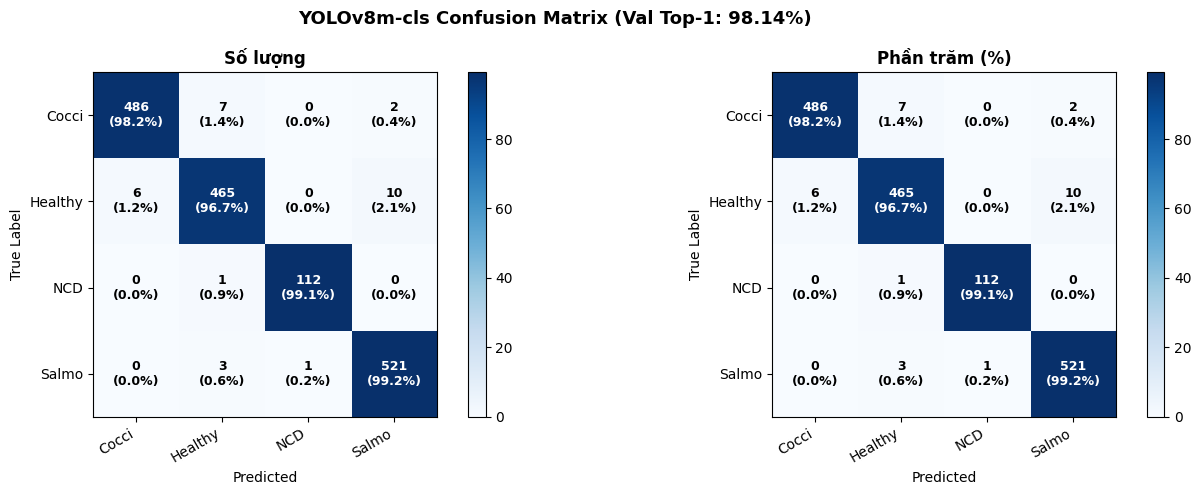

✓ Đã lưu Confusion Matrix tại: /content/drive/MyDrive/AI_Chicken/runs/classify/yolov8m-cls/confusion_matrix_custom.png


In [7]:
cm      = confusion_matrix(all_labels, all_preds, labels=CLASSES_LIST)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'YOLOv8m-cls Confusion Matrix (Val Top-1: {top1_val*100:.2f}%)',
             fontweight='bold', fontsize=13)

for ax, (data, title) in zip(axes, [
    (cm,      'Số lượng'),
    (cm_norm, 'Phần trăm (%)'),
]):
    im = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True Label')
    short = ['Cocci', 'Healthy', 'NCD', 'Salmo']
    ax.set_xticks(range(4)); ax.set_xticklabels(short, rotation=30, ha='right')
    ax.set_yticks(range(4)); ax.set_yticklabels(short)
    for i in range(4):
        for j in range(4):
            val   = cm_norm[i, j]
            color = 'white' if val > 60 else 'black'
            txt   = f'{cm[i,j]}\n({cm_norm[i,j]:.1f}%)'
            ax.text(j, i, txt, ha='center', va='center', color=color, fontsize=9, fontweight='bold')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
save_path = Path(TRAIN_CONFIG['project']) / MODEL_NAME / 'confusion_matrix_custom.png'
plt.savefig(str(save_path), dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'✓ Đã lưu Confusion Matrix tại: {save_path}')

## Bước 7: Tóm tắt kết quả YOLOv8m-cls

In [8]:
model_size_mb = BEST_PT.stat().st_size / 1e6
speed_ms      = val_metrics.speed.get('inference', 0)

print('=' * 60)
print('TÓM TẮT KẾT QUẢ - YOLOv8m-cls')
print('=' * 60)
print(f'Top-1 Accuracy (Val)  : {top1_val*100:.2f}%')
print(f'Top-5 Accuracy (Val)  : {top5_val*100:.2f}%')
print(f'Macro F1-Score        : {macro_f1*100:.2f}%')
print(f'Weighted F1-Score     : {wtd_f1*100:.2f}%')
print(f'Train-Val Gap (OFit)  : {gap*100:.2f}%')
print(f'Inference Speed       : {speed_ms:.2f} ms/img')
print(f'Model Size            : {model_size_mb:.2f} MB')
print(f'Best Model Path       : {BEST_PT}')
print('=' * 60)
print('\n📊 SO SÁNH VỚI CÁC MODEL KHÁC:')
print(f'  YOLOv8n-cls: Top-1 = 97.27%, Macro F1 = 97.62%, Size = ~3MB,  Speed ~0.2ms')
print(f'  YOLOv8s-cls: (xem notebook train_yolov8s_cls.ipynb)')
print(f'  YOLOv8m-cls: Top-1 = {top1_val*100:.2f}%, Macro F1 = {macro_f1*100:.2f}%, Size = {model_size_mb:.1f}MB, Speed {speed_ms:.1f}ms')

TÓM TẮT KẾT QUẢ - YOLOv8m-cls
Top-1 Accuracy (Val)  : 98.14%
Top-5 Accuracy (Val)  : 100.00%
Macro F1-Score        : 98.32%
Weighted F1-Score     : 98.14%
Train-Val Gap (OFit)  : 1.53%
Inference Speed       : 2.21 ms/img
Model Size            : 31.69 MB
Best Model Path       : /content/drive/MyDrive/AI_Chicken/runs/classify/yolov8m-cls/weights/best.pt

📊 SO SÁNH VỚI CÁC MODEL KHÁC:
  YOLOv8n-cls: Top-1 = 97.27%, Macro F1 = 97.62%, Size = ~3MB,  Speed ~0.2ms
  YOLOv8s-cls: (xem notebook train_yolov8s_cls.ipynb)
  YOLOv8m-cls: Top-1 = 98.14%, Macro F1 = 98.32%, Size = 31.7MB, Speed 2.2ms
